# DDPM & DDIM on MNIST

This notebook implements and trains an unconditional Diffusion Model using DDPM and evaluates it with DDIM for faster inference.

## Overview
- **DDPM**: Denoising Diffusion Probabilistic Models (Ho et al., 2020)
- **DDIM**: Denoising Diffusion Implicit Models (Song et al., 2020) for faster sampling
- **Dataset**: MNIST (28x28 grayscale images)
- **Evaluation**: Sample quality across different numbers of diffusion steps

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
import matplotlib.pyplot as plt
import numpy as np

from ddpm import DDPM
from ddpm.callbacks import DDPMSamplingCallback, DiffusionProgressCallback, SampleQualityEvaluator

# Set random seed for reproducibility
pl.seed_everything(42)

Seed set to 42


42

## 1. Data Loading

Load MNIST dataset and normalize to [-1, 1] range (important for diffusion models).

In [3]:
# Transform: normalize to [-1, 1] range
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Maps [0, 1] -> [-1, 1]
])

# Load MNIST
train_dataset = torchvision.datasets.MNIST(
    root='../data',
    train=True,
    download=True,
    transform=transform
)

val_dataset = torchvision.datasets.MNIST(
    root='../data',
    train=False,
    download=True,
    transform=transform
)

# Create dataloaders
batch_size = 128
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Batch size: {batch_size}")

Training samples: 60000
Validation samples: 10000
Batch size: 128


## 2. Model Configuration

Configure DDPM hyperparameters:
- UNet architecture for noise prediction
- Linear beta schedule from 1e-4 to 0.02
- 1000 diffusion timesteps for training
- 50 steps for DDIM inference (20x faster)

In [ ]:
# Model hyperparameters
model = DDPM(
    in_channels=1,              # Grayscale images
    model_channels=64,          # Base UNet channels
    channel_mult=(1, 2, 4),     # Channel multipliers per level
    num_res_blocks=2,           # Residual blocks per level
    num_timesteps=1000,         # Diffusion timesteps
    beta_start=1e-4,            # Starting noise level
    beta_end=0.02,              # Ending noise level
    beta_schedule='linear',     # Noise schedule type``
    lr=2e-4,                    # Learning rate
    num_inference_steps=50,     # DDIM steps for inference
    dropout=0.1,                # Dropout probability
    num_heads=4                 # Attention heads
)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

Model parameters: 14.16M


## 3. Training Setup

Setup callbacks for:
- Periodic sample generation (DDPM vs DDIM)
- Diffusion process visualization
- Model checkpointing
- Learning rate monitoring

In [ ]:
# Callbacks
callbacks = [
    # Generate samples every 10 epochs
    DDPMSamplingCallback(
        num_samples=16,
        log_every_n_epochs=10,
        save_dir='../plots/ddpm',
        ddim_steps=50
    ),
    
    # Visualize diffusion progress at specific epochs
    DiffusionProgressCallback(
        num_samples=8,
        num_steps_to_show=10,
        save_dir='../plots/ddpm',
        log_at_epochs=[50, 100, 200]
    ),
    
    # Save best model
    ModelCheckpoint(
        dirpath='../data/saved_models/ddpm',
        filename='ddpm_mnist_{epoch:03d}_{val_loss:.4f}',
        monitor='val_loss',
        mode='min',
        save_top_k=3
    ),
    
    # Monitor learning rate
    LearningRateMonitor(logging_interval='epoch')
]

# Trainer
trainer = pl.Trainer(
    max_epochs=200,
    accelerator='gpu',
    devices=1,
    callbacks=callbacks,
    log_every_n_steps=50,
    gradient_clip_val=1.0,  # Gradient clipping for stability
    precision='16-mixed' if torch.cuda.is_available() else 32  # Mixed precision if GPU available
)

print(f"Training device: {trainer.accelerator}")
print(f"Number of epochs: {trainer.max_epochs}")

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training device: <pytorch_lightning.accelerators.cuda.CUDAAccelerator object at 0x7ad29d302c20>
Number of epochs: 200


## 4. Train Model

Train the DDPM model. This will:
1. Learn to predict noise added at each timestep
2. Generate samples periodically to monitor progress
3. Save the best models based on validation loss

In [6]:
# Train
trainer.fit(model, train_loader, val_loader)

You are using a CUDA device ('NVIDIA GeForce RTX 5090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/xgeoadmin/miniconda3/envs/cuda-ml/lib/python3.10/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name  | Type | Params | Mode 
---------------------------------------
0 | model | UNet | 14.2 M | train
---------------------------------------
14.2 M    Trainable params
0         Non-trainable params
14.2 M    Total params
56.637    Total estimated model params size (MB)
288       Modules in train mode
0         Modules i

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/xgeoadmin/miniconda3/envs/cuda-ml/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## 5. Sample Quality Evaluation

Compare sample quality between DDPM and DDIM with different numbers of inference steps.

**Goal**: Show that DDIM can produce similar quality samples with far fewer steps.

In [7]:
# Load best checkpoint
best_model_path = trainer.checkpoint_callback.best_model_path
print(f"Loading best model from: {best_model_path}")
model = DDPM.load_from_checkpoint(best_model_path)
model.eval()
model = model.to('cuda' if torch.cuda.is_available() else 'cpu')

Loading best model from: /home/xgeoadmin/Nazar/ucu-genai-cv-2025/data/saved_models/ddpm/ddpm_mnist_epoch=080_val_loss=0.0196.ckpt


In [9]:
# Evaluate sample quality at different step counts
evaluator = SampleQualityEvaluator(
    num_samples=64,
    ddim_step_counts=[10, 25, 50, 100, 200],
    save_dir='../plots/ddpm'
)

# Run evaluation
with torch.no_grad():
    # DDPM (full 1000 steps)
    print("Generating DDPM samples (1000 steps)...")
    ddpm_samples = model.sample(
        num_samples=64,
        method='ddpm',
        return_all_steps=False
    )
    
    # DDIM with varying steps
    ddim_samples_dict = {}
    for steps in [10, 25, 50, 100, 200]:
        print(f"Generating DDIM samples ({steps} steps)...")
        samples = model.sample(
            num_samples=64,
            method='ddim',
            num_inference_steps=steps,
            return_all_steps=False
        )
        ddim_samples_dict[steps] = samples
    
    # Plot comparison
    evaluator._plot_comparison(ddpm_samples, ddim_samples_dict, trainer.current_epoch)

Generating DDPM samples (1000 steps)...
Generating DDIM samples (10 steps)...
Generating DDIM samples (25 steps)...
Generating DDIM samples (50 steps)...
Generating DDIM samples (100 steps)...
Generating DDIM samples (200 steps)...

Sample quality comparison saved to ../plots/ddpm


## 6. Visualize Diffusion Process

Show how images gradually emerge from noise during the reverse diffusion process.

Generating diffusion process visualization...


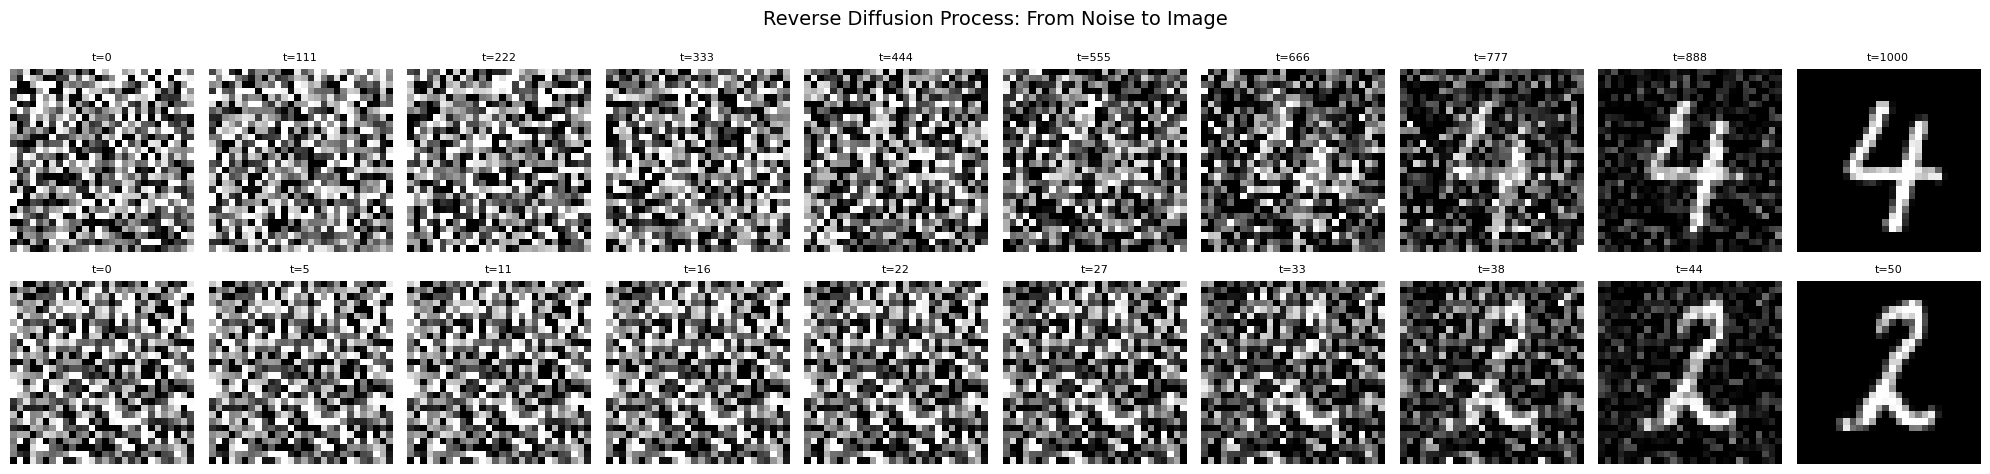

In [10]:
# Generate with all intermediate steps
print("Generating diffusion process visualization...")
with torch.no_grad():
    final_ddpm, ddpm_steps = model.sample(
        num_samples=1,
        method='ddpm',
        return_all_steps=True
    )
    
    final_ddim, ddim_steps = model.sample(
        num_samples=1,
        method='ddim',
        num_inference_steps=50,
        return_all_steps=True
    )

# Select timesteps to visualize
num_steps_to_show = 10
ddpm_indices = np.linspace(0, len(ddpm_steps) - 1, num_steps_to_show, dtype=int)
ddim_indices = np.linspace(0, len(ddim_steps) - 1, num_steps_to_show, dtype=int)

fig, axes = plt.subplots(2, num_steps_to_show, figsize=(20, 5))

# DDPM progression
for i, idx in enumerate(ddpm_indices):
    img = ddpm_steps[idx][0].cpu()
    img = (img + 1) / 2  # Denormalize
    axes[0, i].imshow(img.squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[0, i].set_title(f't={idx}', fontsize=8)

# DDIM progression
for i, idx in enumerate(ddim_indices):
    img = ddim_steps[idx][0].cpu()
    img = (img + 1) / 2
    axes[1, i].imshow(img.squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')
    axes[1, i].set_title(f't={idx}', fontsize=8)

axes[0, 0].set_ylabel('DDPM\n(1000 steps)', fontsize=10, rotation=0, ha='right', va='center')
axes[1, 0].set_ylabel('DDIM\n(50 steps)', fontsize=10, rotation=0, ha='right', va='center')

plt.suptitle('Reverse Diffusion Process: From Noise to Image', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/ddpm/diffusion_process_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Generate Final Samples

Generate a large batch of samples for qualitative evaluation.

Generating final DDPM samples...


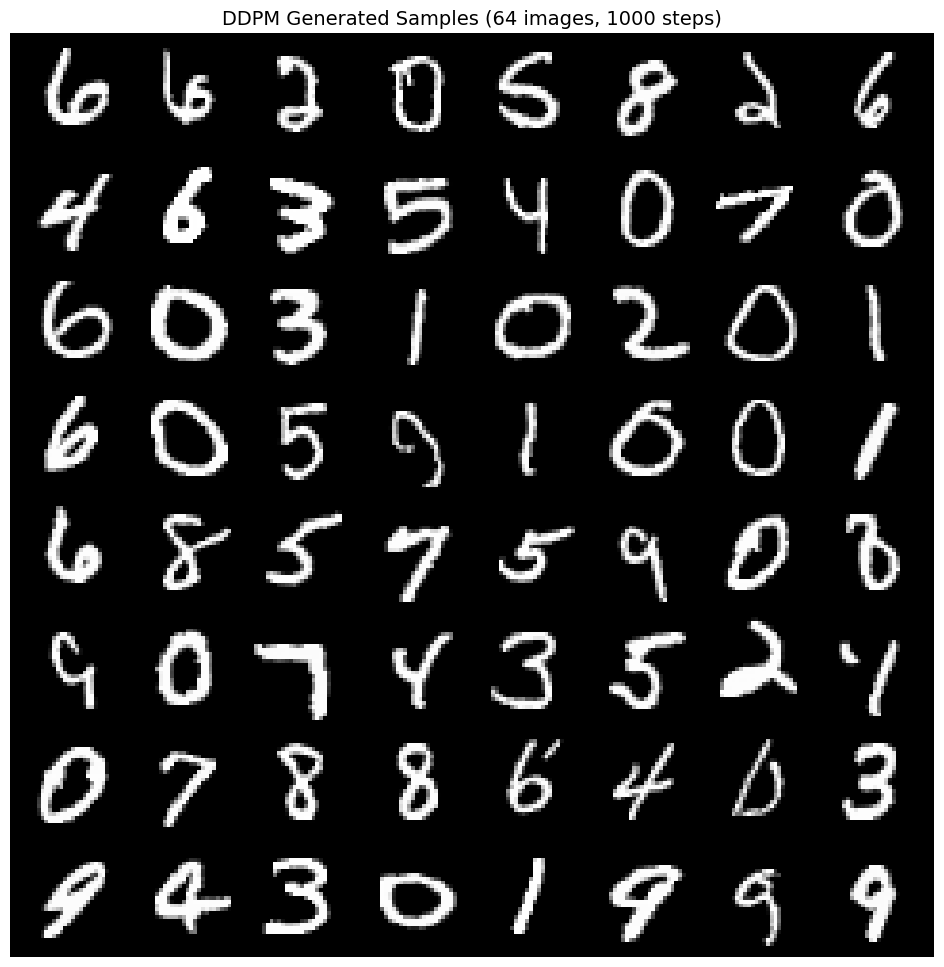

In [11]:
# Generate 64 samples with DDPM
print("Generating final DDPM samples...")
with torch.no_grad():
    ddpm_samples = model.sample(
        num_samples=64,
        method='ddpm',
        return_all_steps=False
    )

# Visualize
grid = torchvision.utils.make_grid(
    ddpm_samples.cpu(),
    nrow=8,
    normalize=True,
    value_range=(-1, 1)
)

plt.figure(figsize=(12, 12))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)), cmap='gray')
plt.title('DDPM Generated Samples (64 images, 1000 steps)', fontsize=14)
plt.axis('off')
plt.savefig('../plots/ddpm/ddpm_final_samples.png', dpi=150, bbox_inches='tight')
plt.show()

Generating final DDIM samples...


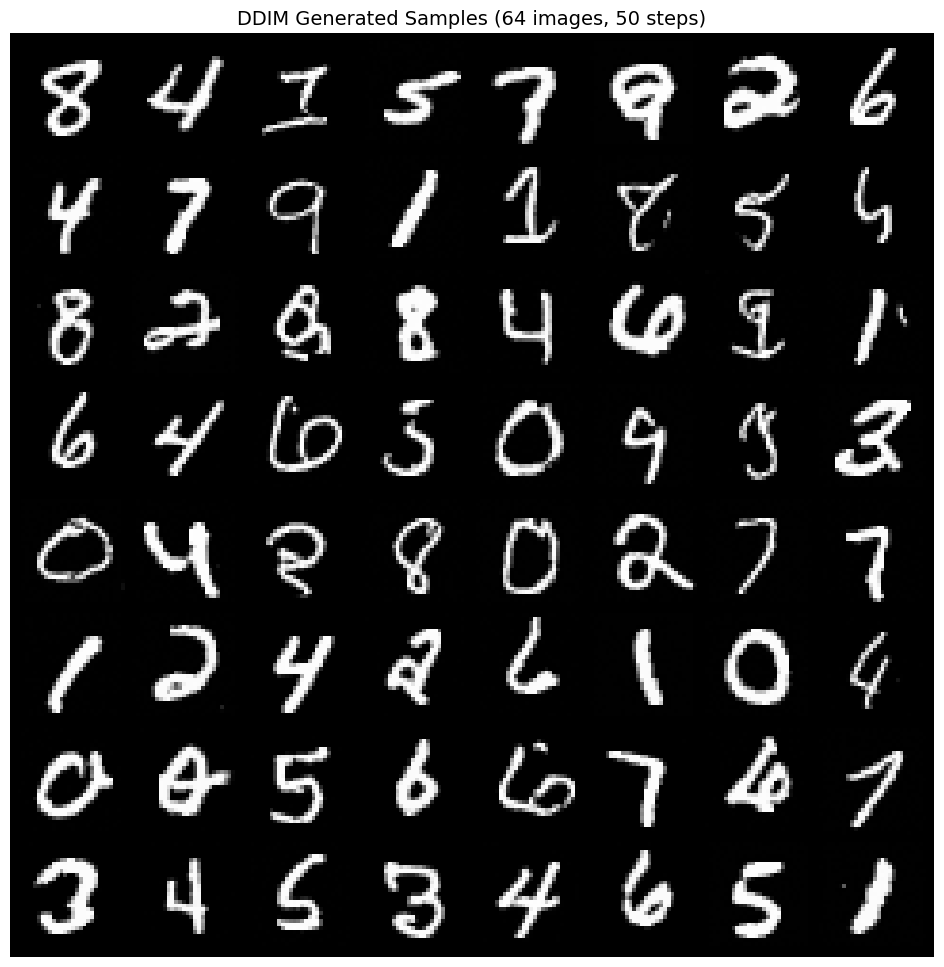

In [12]:
# Generate 64 samples with DDIM (50 steps)
print("Generating final DDIM samples...")
with torch.no_grad():
    ddim_samples = model.sample(
        num_samples=64,
        method='ddim',
        num_inference_steps=50,
        return_all_steps=False
    )

# Visualize
grid = torchvision.utils.make_grid(
    ddim_samples.cpu(),
    nrow=8,
    normalize=True,
    value_range=(-1, 1)
)

plt.figure(figsize=(12, 12))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)), cmap='gray')
plt.title('DDIM Generated Samples (64 images, 50 steps)', fontsize=14)
plt.axis('off')
plt.savefig('../plots/ddpm/ddim_final_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Inference Speed Comparison

Measure and compare inference time between DDPM and DDIM.

Benchmarking DDPM (1000 steps)...
DDPM time: 6.83s for 16 samples
Benchmarking DDIM (10 steps)...
DDIM time: 0.07s for 16 samples
Benchmarking DDIM (20 steps)...
DDIM time: 0.14s for 16 samples
Benchmarking DDIM (50 steps)...
DDIM time: 0.34s for 16 samples
Benchmarking DDIM (100 steps)...
DDIM time: 0.68s for 16 samples
Benchmarking DDIM (200 steps)...
DDIM time: 1.37s for 16 samples


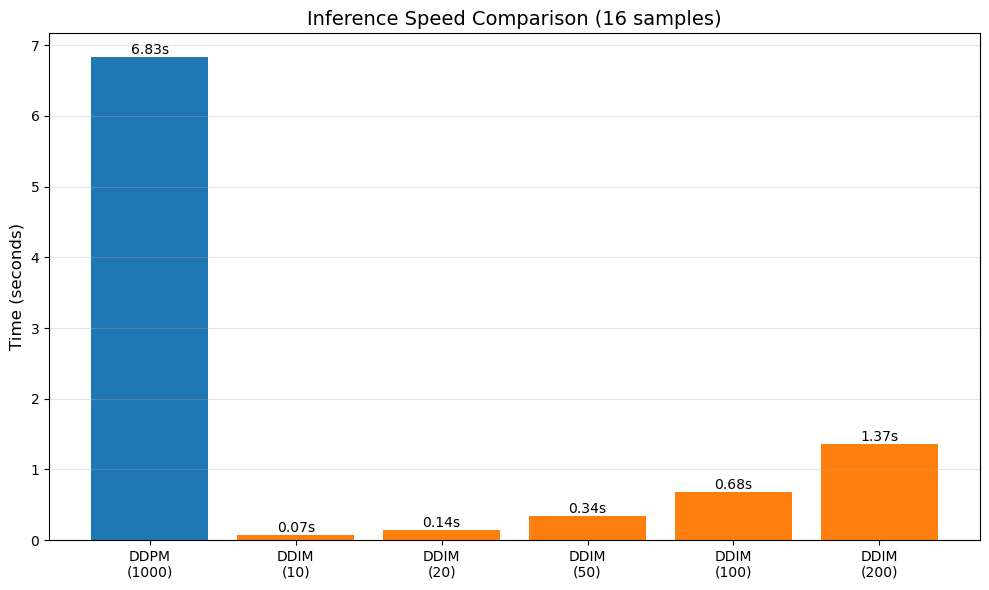


Speedup with DDIM (50 steps): 19.97x


In [13]:
import time

# Benchmark DDPM
print("Benchmarking DDPM (1000 steps)...")
start = time.time()
with torch.no_grad():
    _ = model.sample(num_samples=16, method='ddpm')
ddpm_time = time.time() - start
print(f"DDPM time: {ddpm_time:.2f}s for 16 samples")

# Benchmark DDIM with different step counts
ddim_times = {}
for steps in [10, 20, 50, 100, 200]:
    print(f"Benchmarking DDIM ({steps} steps)...")
    start = time.time()
    with torch.no_grad():
        _ = model.sample(num_samples=16, method='ddim', num_inference_steps=steps)
    ddim_times[steps] = time.time() - start
    print(f"DDIM time: {ddim_times[steps]:.2f}s for 16 samples")

# Plot comparison
plt.figure(figsize=(10, 6))
step_counts = [1000] + list(ddim_times.keys())
times = [ddpm_time] + list(ddim_times.values())
labels = ['DDPM\n(1000)'] + [f'DDIM\n({s})' for s in ddim_times.keys()]

bars = plt.bar(labels, times, color=['#1f77b4'] + ['#ff7f0e'] * len(ddim_times))
plt.ylabel('Time (seconds)', fontsize=12)
plt.title('Inference Speed Comparison (16 samples)', fontsize=14)
plt.grid(axis='y', alpha=0.3)

# Add time labels on bars
for bar, t in zip(bars, times):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{t:.2f}s',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../plots/ddpm/inference_speed_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSpeedup with DDIM (50 steps): {ddpm_time / ddim_times[50]:.2f}x")

## Summary

This notebook demonstrated:
1. **DDPM Training**: Trained an unconditional diffusion model on MNIST
2. **DDIM Sampling**: Implemented faster inference with fewer steps
3. **Quality Evaluation**: Compared sample quality across different step counts
4. **Speed Comparison**: Measured inference speedup with DDIM

**Key Findings**:
- DDPM produces high-quality samples but requires 1000 denoising steps
- DDIM achieves similar quality with 50 steps (~20x faster)
- Both methods successfully generate diverse MNIST digits
- The diffusion process gradually refines noise into recognizable digits